Everything below focuses on visualization and biological interpretation.

```{important}
This section assumes you have already generated for all RBP datasets (using the `reproducibility/Fig7/data_preprocess.ipynb` notebook) and saved the following files:

- `results/reproducibility/gwas_resources/match_GWAS.csv`  
  BRIDGE variant scores merged with `gene_name` and GWAS `p_value`.

- `results/reproducibility/gwas_resources/mutation_scores_with_gene.csv`  
  Per-variant BRIDGE scores (REF/ALT and derived impact metrics) annotated with gene information, used by the heatmap pipeline.

**Note:**

Running the full pipeline across all RBPs can be time-consuming.  
To make it easier to reproduce the figures directly, we also provide these precomputed files on `Figshare`.
```

### Step 5A — Cell-line-specific vs shared mutation loci

This step visualizes how strong the mutation impact is per locus/cell.

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: grid

ComplexHeatmap version 2.18.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformati

pdf 
  2

Heatmap saved to: /fs1/private/user/wangyubo/code/BRIDGE_folder/BRIDGE_reproducibility/notebooks/Fig7/cell_specific.png



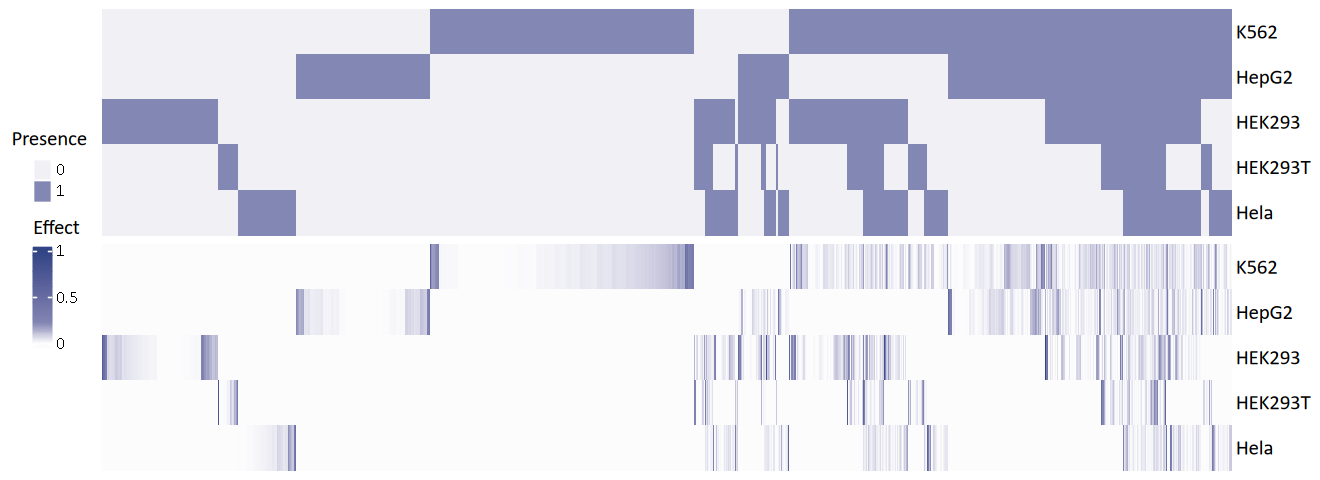

In [1]:
## ===============================================================
##  cell_specific_heatmap.R  —  Heatmap of cell-line-specific vs shared mutation loci
## ===============================================================
# Inputs:
#   - ../../../../results/reproducibility/gwas_resources/mutation_scores_with_gene.csv
#     Required columns: chr, start_pos, end_pos, cell, ref_score, alt_score
#
# Outputs:
#   - cell_specific.png (300 dpi)
#
# Notes:
#   - If a locus has multiple records within the same (locus, cell), we average abs_diff.
#   - "locus" is defined as "chr:start_pos:end_pos" (string key).

# ------------ 0. Dependencies ------------------------------------------------
# Install packages once if needed: install.packages("...") / BiocManager::install("...")
library(tidyverse)
library(ComplexHeatmap)
library(circlize)
library(showtext)     # TrueType font embedding
library(systemfonts)  # Helps detect system fonts
library(grid)         # gpar(), unit()

# ------------ 1. Register & activate Calibri --------------------------------
font_add(
  family  = "Calibri",
  regular = "/home/wangyubo/.fonts/calibri.ttf"
)
showtext_auto()                               # Render subsequent plots via showtext
font_calibri <- gpar(fontfamily = "Calibri")  # Reusable text style

# ------------ 2. Load data & preprocess -------------------------------------
output_mutation_scores_with_gene <- "../../results/reproducibility/gwas_resources/mutation_scores_with_gene.csv"
csv_path <- output_mutation_scores_with_gene

df <- read_csv(csv_path) %>%
  mutate(
    sig_ref  = plogis(ref_score),
    sig_alt  = plogis(alt_score),
    abs_diff = abs(sig_ref - sig_alt),
    locus    = paste(chr, start_pos, end_pos, sep = ":")
  )

# A given (locus, cell) may appear multiple times; average within-group.
df_clean <- df %>%
  group_by(locus, cell) %>%
  summarise(abs_diff = mean(abs_diff), .groups = "drop")

cell_order <- c("K562", "HepG2", "HEK293", "HEK293T", "Hela")

# ------------ 3. Build presence / effect matrices ---------------------------
presence <- df_clean %>%
  select(locus, cell) %>%
  distinct() %>%
  mutate(presence = 1) %>%
  pivot_wider(
    names_from  = cell,
    values_from = presence,
    values_fill = list(presence = 0)
  ) %>%
  mutate(
    pattern = apply(select(., all_of(cell_order)), 1,
                    function(x) paste(names(x)[x == 1], collapse = "+")),
    n_cells = rowSums(select(., all_of(cell_order))),
    group   = if_else(n_cells == 1, "specific", "sharing")
  )

effect <- df_clean %>%
  pivot_wider(
    names_from  = cell,
    values_from = abs_diff,
    values_fill = list(abs_diff = 0)
  )

# Convert to matrices (rows = cell lines, columns = loci)
presence_mat <- presence %>%
  select(locus, all_of(cell_order)) %>%
  column_to_rownames("locus") %>% as.matrix() %>% t()

effect_mat <- effect %>%
  select(locus, all_of(cell_order)) %>%
  column_to_rownames("locus") %>% as.matrix() %>% t()

# ------------ 4. Custom ordering: cell-specific first, then shared -----------
get_order_by_group <- function(df_group, mat) {
  sub_mat <- mat[, df_group$locus, drop = FALSE]
  if (ncol(sub_mat) > 1) {
    sub_mat[is.na(sub_mat)] <- 0
    clust <- hclust(dist(t(sub_mat)))
    colnames(sub_mat)[clust$order]
  } else {
    df_group$locus
  }
}

ordered_loci <- character(0)

# 4.1 Cell-specific groups (group by the single "main_cell")
specific_groups <- presence %>%
  filter(group == "specific") %>%
  mutate(main_cell = str_remove(pattern, "\\+.*$")) %>%
  group_by(main_cell) %>% group_split()

for (grp in specific_groups) {
  ordered_loci <- c(ordered_loci, get_order_by_group(grp, effect_mat))
}

# 4.2 Shared groups (group by exact pattern, e.g., "K562+HepG2")
sharing_groups <- presence %>%
  filter(group == "sharing") %>%
  group_by(pattern) %>% group_split()

for (grp in sharing_groups) {
  ordered_loci <- c(ordered_loci, get_order_by_group(grp, effect_mat))
}

# Reorder columns by our custom locus order
presence_mat <- presence_mat[, ordered_loci, drop = FALSE]
effect_mat   <- effect_mat[, ordered_loci, drop = FALSE]

# ------------ 5. Color mapping & Heatmap objects ----------------------------
col_fun <- colorRamp2(
  c(0,
    mean(effect_mat, na.rm = TRUE) + 0.2,
    max(effect_mat, na.rm = TRUE)),
  c("#FCFCFD", "#8385b3", "#314485")
)

ht_presence <- Heatmap(
  presence_mat,
  name              = "Presence",
  col               = c("0" = "#f1f0f5", "1" = "#8387b3"),
  row_order         = cell_order,
  column_order      = colnames(presence_mat),
  show_column_names = FALSE,
  cluster_columns   = FALSE,
  cluster_rows      = FALSE,
  row_names_gp      = font_calibri,
  column_names_gp   = font_calibri,
  heatmap_legend_param = list(
    title_position = "topcenter",
    title_gp  = font_calibri,
    labels_gp = font_calibri
  )
)

ht_effect <- Heatmap(
  effect_mat,
  name              = "Effect",
  col               = col_fun,
  row_order         = cell_order,
  column_order      = colnames(effect_mat),
  show_column_names = FALSE,
  cluster_columns   = FALSE,
  cluster_rows      = FALSE,
  row_names_gp      = font_calibri,
  column_names_gp   = font_calibri,
  heatmap_legend_param = list(
    title_gp  = font_calibri,
    labels_gp = font_calibri
  )
)

# ------------ 6. Export PNG (or PDF) ----------------------------------------
# Wrap the draw call so on-screen rendering and file saving stay identical.
draw_heatmap <- function() {
  draw(
    ht_presence %v% ht_effect,
    heatmap_legend_side = "left",
    padding = unit(c(2, 7, 2, 2), "mm")
  )
}

# 6.1 Display in Jupyter / RStudio
options(repr.plot.width = 11, repr.plot.height = 4)
draw_heatmap()

# 6.2 Save PNG
out_png <- "cell_specific.png"
dir.create(dirname(out_png), showWarnings = FALSE, recursive = TRUE)

showtext_opts(dpi = 300)
png(out_png, width = 11, height = 4, units = "in", res = 300)
draw_heatmap()
dev.off()

message("Heatmap saved to: ", normalizePath(out_png, winslash = "/"))
